In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

In [2]:
def f1(x):
  x1, x2 = x
  return -(3*(x1 - 0.25)**2 + 5*(x2 - 0.75)**2 + 1)

def f2(x):
  x1, x2 = x
  return 14-2*(x1 - 0.5)**2 - 4*(x2 - 0.5)**2

x1_range = np.linspace(0, 1, 50)
x2_range = np.linspace(0, 1, 50)
X1, X2 = np.meshgrid(x1_range, x2_range)
X = np.vstack([X1.ravel(), X2.ravel()]).T

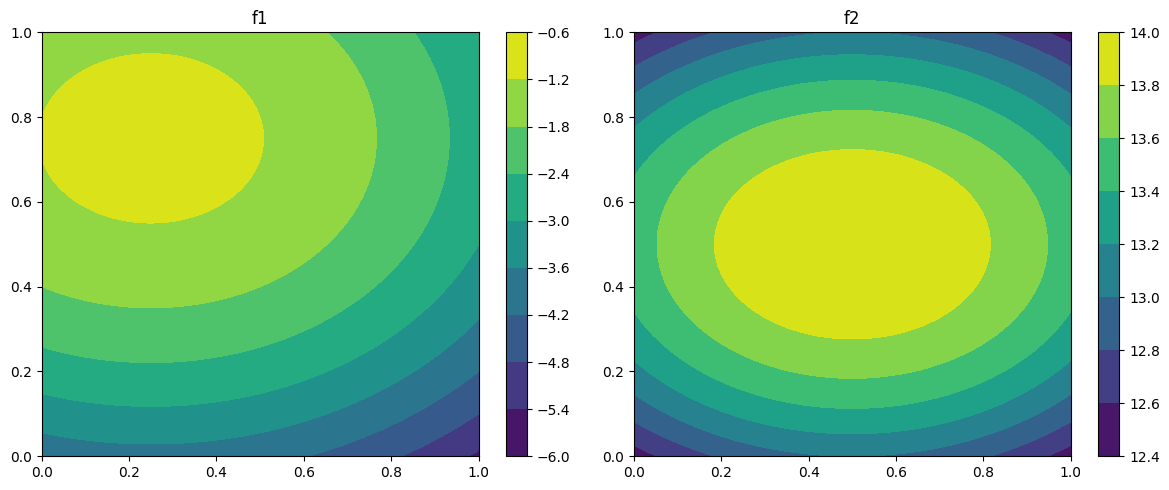

In [3]:
F1 = np.array([f1(x) for x in X]).reshape(X1.shape)
F2 = np.array([f2(x) for x in X]).reshape(X1.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
cs1 = ax1.contourf(X1, X2, F1)
cs2 = ax2.contourf(X1, X2, F2)
fig.colorbar(cs1, ax=ax1)
fig.colorbar(cs2, ax=ax2)
ax1.set_title("f1")
ax2.set_title("f2")
plt.tight_layout()
plt.show()

In [4]:
import numpy as np
def SECovFunc(xp, xq, l, sigma_f):
  return(sigma_f**2 * np.exp(-1/(2*l**2) * np.linalg.norm(xp-xq)**2))

def fillCovMat(X1, X2, l, sigma_f, sigma_n=0):
  sX1 = X1.shape
  sX2 = X2.shape
  K = np.zeros((sX1[0],sX2[0]))

  for i in range(sX1[0]):
    for j in range(sX2[0]):
      K[i,j] = SECovFunc(X1[i,:], X2[j,:], l, sigma_f)

  if sigma_n > 0:
    K = K + sigma_n**2 * np.eye(sX1[0])

  return(K)

def gpNegLogMarLike(X,y,sigma_n):
  def parOpt(params):
    l = params[0]
    sigma_f = params[1]
    #sigma_n = params[2]

    n = X.shape[0]
    K = fillCovMat(X,X,l,sigma_f,sigma_n)
    L = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T,np.linalg.solve(L,y))

    return(-1*(-1/2*y.T@alpha - np.sum(np.log(np.diag(L))) - n/2*np.log(2*np.pi)))
  return parOpt

import scipy as sp
def gpHPTuning(X,y,l_i,sigma_f_i,sigma_n):
  return(sp.optimize.minimize(gpNegLogMarLike(X,y,sigma_n),[l_i,sigma_f_i]))

def gpPosteriors(X,y,Xt,l,sigma_f,sigma_n):
  if len(y.shape) == 1:
    y = y[:,None]
  if len(Xt.shape) ==1:
    Xt = Xt[None,:]

  n = X.shape[0]
  K = fillCovMat(X,X,l,sigma_f,sigma_n)
  Kt = fillCovMat(Xt,X,l,sigma_f)
  Ktt = fillCovMat(Xt,Xt,l,sigma_f)

  L = np.linalg.cholesky(K)
  alpha = np.linalg.solve(L.T,np.linalg.solve(L,y))
  mu = Kt@alpha

  v = np.linalg.solve(L.T,np.linalg.solve(L,Kt.T))
  cov = Ktt - Kt@v

  return(mu,cov)

In [5]:
initial_designs = np.array([[0.25, 0.25], [0.75, 0.75], [0.375, 0.5], [0.125, 0.875]])
f1_values = np.array([f1(x) for x in initial_designs])
f2_values = np.array([f2(x) for x in initial_designs])
df = pd.DataFrame(initial_designs, columns=['x1', 'x2'])
df['f1'] = f1_values
df['f2'] = f2_values
df

,x1,x2,f1,f2
0,0.250,0.250,-2.250000,13.62500
1,0.750,0.750,-1.750000,13.62500
2,0.375,0.500,-1.359375,13.96875
3,0.125,0.875,-1.125000,13.15625


In [6]:
X_init = df.iloc[:,:2].values
Y1_init = df.iloc[:,2].values
Y2_init = df.iloc[:,3].values

#scaler = StandardScaler()
#X_init = scaler.fit_transform(X_init)

In [8]:
[l1,sigma_f1] = gpHPTuning(X_init,Y1_init,1,1,0.1).x
[l2,sigma_f2] = gpHPTuning(X_init,Y2_init,1,1,0.1).x

mu1,cov1 = gpPosteriors(X_init,Y1_init,X,l1,sigma_f1,0.1)
mu2,cov2 = gpPosteriors(X_init,Y2_init,X,l2,sigma_f2,0.1)

In [27]:
mu1,cov1 = gpPosteriors(X_init,Y1_init,scaler.transform(X),1,1,0.1)
mu2,cov2 = gpPosteriors(X_init,Y2_init,scaler.transform(X),1,1,0.1)

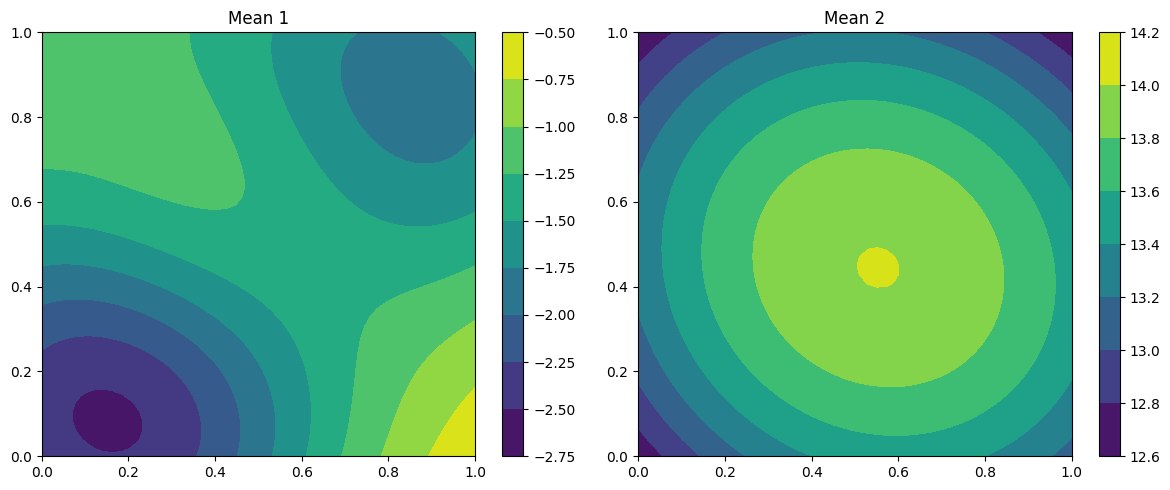

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
cs1 = ax1.contourf(X1, X2, mu1.reshape(X1.shape))
cs2 = ax2.contourf(X1, X2, mu2.reshape(X1.shape))
fig.colorbar(cs1, ax=ax1)
fig.colorbar(cs2, ax=ax2)
ax1.set_title("Mean 1")
ax2.set_title("Mean 2")
plt.tight_layout()
plt.show()

In [10]:
kernel = C(1.0, (1e-04, 1e2)) * RBF(1.0, (2.5e-02, 1e2))
gp_f1 = GaussianProcessRegressor(kernel=kernel, optimizer=None)
gp_f2 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

gp_f1.fit(initial_designs, f1_values)
gp_f2.fit(initial_designs, f2_values)

f1_mean, f1_std = gp_f1.predict(X, return_std=True)
f2_mean, f2_std = gp_f2.predict(X, return_std=True)

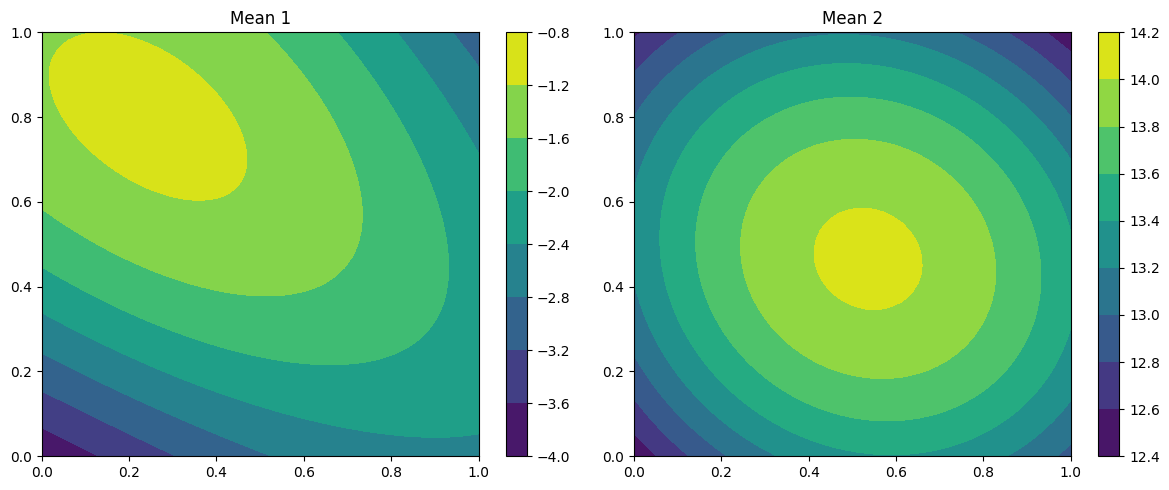

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
cs1 = ax1.contourf(X1, X2, f1_mean.reshape(X1.shape))
cs2 = ax2.contourf(X1, X2, f2_mean.reshape(X1.shape))
fig.colorbar(cs1, ax=ax1)
fig.colorbar(cs2, ax=ax2)
ax1.set_title("Mean 1")
ax2.set_title("Mean 2")
plt.tight_layout()
plt.show()